Crie um Notebook no Google Colab com o nome [ELT574 <Matrícula> Atividade 2], modificando o campo <Matrícula> pela sua matrícula do Sapiens (Exemplo: ELT574 12700-0 Atividade 2). Conforme o roteiro abaixo, responda os questionamento e implemente rotinas para realizar os cálculos necessários.
Utilize o notebook disponibilizado para o problema de classificação multiclasse Fashion MNIST e, ajustando diferentes hiperparâmetros de treinamento, tente atingir 90% de acurácia nas inferências. Apresente o gráfico de treinamento e validação da função de loss. Caso não consiga atingir este nível de precisão, mostre qual foi seu melhor resultado.
Todas as questões devem ser inseridas no notebook do Google Colab. O link para o notebook deve ser enviado como resposta da tarefa.

In [ ]:
# Importação das bibliotecas

import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
from tensorflow import keras






In [ ]:
# Dataset com  os dados de teste e treinamneto separados

fashion_mnist=keras.datasets.fashion_mnist


(X_train_full,y_train_full),(X_test,y_test)=fashion_mnist.load_data()

In [ ]:
# Dividindo em validação e treino, e normalizando os pixels

X_valid, X_train = X_train_full[:5000] / 255.0, X_train_full[5000:] / 255.0
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

X_test=X_test/255.0

In [ ]:
# Preparando os dados para o ajuste de uma MLPClassifier


# Achata as imagens de treino: de (55000, 28, 28) para (55000, 784)
X_train_flat = X_train.reshape(X_train.shape[0], -1)

# Transforma (5000, 28, 28) em (5000, 784)
X_valid_flat = X_valid.reshape(X_valid.shape[0], -1)


# Transforma (10000, 28, 28) em (10000, 784)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

In [63]:
# Importa a classe MLPClassifier do módulo de redes neurais do sklearn
from sklearn.neural_network import MLPClassifier

# Cria o modelo MLP (Multilayer Perceptron) com os hiperparâmetros escolhidos
mlp_clf = MLPClassifier(

    # 1 camada oculta com 30 neurônios
    hidden_layer_sizes=(30,),

    # número máximo de épocas de treino
    max_iter=30,

    # função de ativação usada nos neurônios da camada oculta
    activation='relu',

)

# Treina o modelo com os dados de treino já achatados (784 features por imagem)
mlp_clf.fit(X_train_flat, y_train)


# Calcula a acurácia no conjunto de validação
val_accuracy = mlp_clf.score(X_valid_flat, y_valid)
print(f"Acurácia de validação: {val_accuracy:.4f}")

# Calcula a acurácia no conjunto de teste
test_accuracy = mlp_clf.score(X_test_flat, y_test)
print(f"Acurácia de teste: {test_accuracy:.4f}")


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


Acurácia de validação: 0.8844
Acurácia de teste: 0.8724


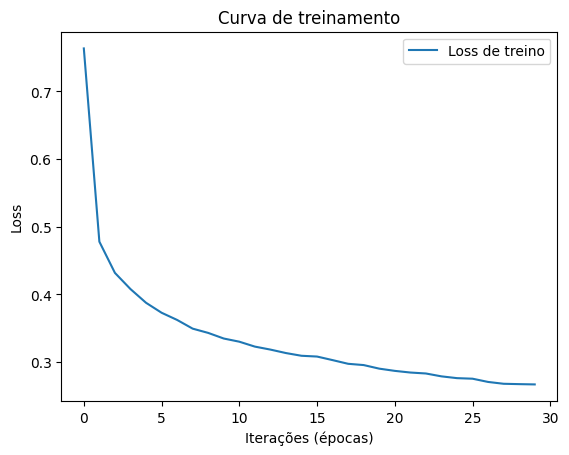

In [64]:
import matplotlib.pyplot as plt

plt.plot(mlp_clf.loss_curve_, label='Loss de treino')
plt.xlabel('Iterações (épocas)')
plt.ylabel('Loss')
plt.title('Curva de treinamento')
plt.legend()
plt.show()



## Para fins didáticos, optei em implementar o MLPClassifier como primeiro modelo a ser treinado. Utilizei uma arquitetura minimalista: 1 camada oculta com 30 neurônios, ativação ReLU, 30 iterações.

## Observação: O MLPClassifier não disponibiliza a loss de validação durante o treino — apenas loss_curve_ (loss de treino). .

## Resultados: O modelo atingiu 88,44% de acurácia na validação e 87,24% no teste — abaixo da meta de 90%, mas esperado dada a simplicidade da arquitetura (poucos neurônios, poucas iterações).

In [57]:


import tensorflow as tf
from tensorflow import keras

def build_model_clf(
    n_hidden=2,
    n_neurons=30,
    learning_rate=0.001,
    activation="relu",
    input_shape=(28, 28)
):
    model = keras.models.Sequential()

    model.add(keras.layers.Input(shape=input_shape))
    model.add(keras.layers.Flatten())

    for _ in range(n_hidden):
        model.add(
            keras.layers.Dense(
                int(n_neurons), # <-- Força a conversão para int nativo
                activation=activation
            )
        )

    model.add(keras.layers.Dense(10, activation="softmax"))

    optimizer = keras.optimizers.Adam(
        learning_rate=learning_rate
    )

    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer=optimizer,
        metrics=["accuracy"]
    )

    return model

In [58]:

from scipy.stats import reciprocal
from sklearn.model_selection import RandomizedSearchCV
from scikeras.wrappers import KerasClassifier

# 1. Hiperparâmetros a serem testados
param_distribs = {
    "model__n_hidden": [1, 2],
    "model__n_neurons": np.arange(20, 50),
    "model__learning_rate": reciprocal(1e-4, 1e-2),
    "model__activation": ["relu", "sigmoid", "tanh"],
}

# 2. Instanciando o wrapper do SciKeras
keras_clf = KerasClassifier(
    model=build_model_clf,
    epochs=30,
    batch_size=32,
    verbose=0
)

# 3. Configurando a Busca Aleatória
random_search = RandomizedSearchCV(
    estimator=keras_clf,
    param_distributions=param_distribs,
    n_iter=10,             # Número de combinações testadas
    cv=3,                  # Validação cruzada com 3 dobras (folds)
    random_state=42,
    n_jobs=1               # Deixe em 1 para evitar conflitos de GPU/TensorFlow
)

# 4. Executando a busca (passando validação para os callbacks do Keras)
print("Iniciando a busca de hiperparâmetros...")
random_search.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid)
)

print("Busca concluída!")

Iniciando a busca de hiperparâmetros...
Busca concluída!


In [60]:
# Exibe a melhor combinação de hiperparâmetros encontrada pela busca aleatória
# (dicionário com os valores de n_hidden, n_neurons, learning_rate e activation
print(random_search.best_params_)

# Exibe o score (acurácia média) obtido pela melhor combinação de hiperparâmetros
print(random_search.best_score_)

{'model__activation': 'relu', 'model__learning_rate': np.float64(0.0007309539835912913), 'model__n_hidden': 1, 'model__n_neurons': np.int64(46)}
0.884563697443229


In [61]:

# Constrói o modelo final usando os melhores hiperparâmetros encontrados

final_model = build_model_clf(
    n_hidden=1,
    n_neurons=46,
    learning_rate=0.0007309539835912913,
    activation="relu"
)


In [62]:
# Treina esse modelo, capturando o histórico (loss/val_loss por época)
history = final_model.fit(
    X_train, y_train,
    epochs=30,
    validation_data=(X_valid, y_valid)
)

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8065 - loss: 0.5622 - val_accuracy: 0.8490 - val_loss: 0.4436
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8506 - loss: 0.4198 - val_accuracy: 0.8626 - val_loss: 0.3992
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8641 - loss: 0.3819 - val_accuracy: 0.8652 - val_loss: 0.3829
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8704 - loss: 0.3593 - val_accuracy: 0.8676 - val_loss: 0.3688
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8769 - loss: 0.3415 - val_accuracy: 0.8670 - val_loss: 0.3774
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8808 - loss: 0.3286 - val_accuracy: 0.8742 - val_loss: 0.3412
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8840 - loss: 0.3164 - val_accuracy: 0.8676 - val_loss: 0.3606
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8871 - loss: 0.3080 - 

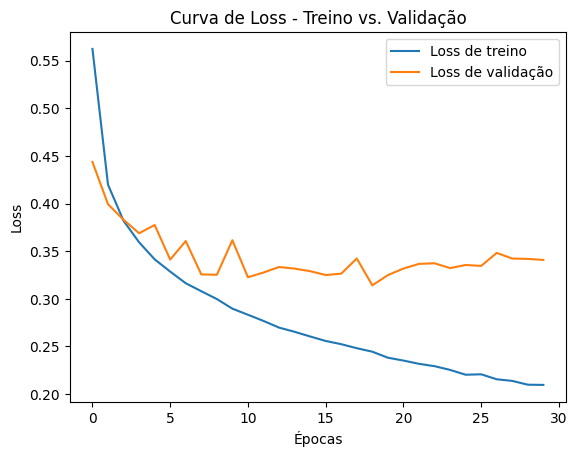

In [65]:
import matplotlib.pyplot as plt

# Plota a loss de treino e de validação, por época
plt.plot(history.history['loss'], label='Loss de treino')
plt.plot(history.history['val_loss'], label='Loss de validação')

plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.title('Curva de Loss - Treino vs. Validação')
plt.legend()
plt.show()

In [66]:
# Acurácia do melhor modelo no conjunto de validação
val_loss, val_accuracy = final_model.evaluate(X_valid, y_valid, verbose=0)
print(f"Acurácia de validação: {val_accuracy:.4f}")

# Avalia no conjunto de teste
test_loss, test_accuracy = final_model.evaluate(X_test, y_test, verbose=0)
print(f"Acurácia de teste: {test_accuracy:.4f}")

Acurácia de validação: 0.8882
Acurácia de teste: 0.8764




Como segundo modelo, implementei uma rede MLP usando o Keras Sequential, encapsulada numa função
parametrizável que permite ajustar número de camadas ocultas, número de neurônios.


A melhor combinação encontrada foi: 1 camada oculta, 46 neurônios, ativação ReLU e learning rate ≈ 0,00073.


**Resultados: o modelo atingiu 88,82% de acurácia na validação e 87,64% no teste** — uma leve melhora
em relação ao MLPClassifier, mas ainda abaixo da meta de 90%.